# Polychronous Multi-Modal Spiking Memory

Notebook demo for the v1.1 roadmap.

This notebook uses `spiking_multimodal_memory.py` as the source of truth and demonstrates:

- v2: pure neural retrieval without symbolic shortcuts
- v3: multimodal association, semantic text encoding, and CA1 readout
- v4: episodic sequencing and provenance
- v5: continual memory, consolidation, and false-retrieval checks
- v6: research harness with dropout, separation, continuity, and exactness metrics


In [1]:
%matplotlib inline

from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np

from spiking_multimodal_memory import MultiModalMemory

np.set_printoptions(precision=3, suppress=True)


def topk(items, k=5):
    return sorted(items.items(), key=lambda item: item[1], reverse=True)[:k]


def print_metric_block(title, metrics):
    print(title)
    for key, value in metrics.items():
        print(f"  {key}: {value}")


print('Notebook connected to the current implementation')


Notebook connected to the current implementation


## v2 and v3

Pure neural retrieval, then cross-modal association through the learned multimodal path and semantic text encoding.


In [2]:
mem = MultiModalMemory(use_text=True, seed=42, text_use_pretrained=True)

alice_sql = {
    'age': 30,
    'salary': 85000,
    'city': 'NYC',
    'role': 'Engineer',
    'dept': 'AI',
}
alice_graph = (0, 'WORKS_AT', 1)
alice_text = 'Alice works at Google'

for _ in range(5):
    learn = mem.encode_episode(alice_sql, alice_graph, text=alice_text)

partial_cue = {'age': 30, 'salary': 85000}
retrieved = mem.retrieve(sql_cue=partial_cue, duration=50.0)
control = mem.retrieve(
    sql_cue={'age': 52, 'salary': 42000, 'city': 'Austin', 'role': 'Designer', 'dept': 'Ops'},
    duration=50.0,
)

print(f"Stored CA3 assembly size: {len(learn['ca3_active'])}")
print(f"Retrieved CA3 size from partial cue: {len(retrieved['ca3_active'])}")
print(f"Control CA3 size: {len(control['ca3_active'])}")
print()
print_metric_block('Graph metrics', mem.compute_graph_retrieval_accuracy(retrieved, alice_graph))
print()
print('Top SQL readout:')
pprint(topk(retrieved['sql_reconstruction'], 8))
print('Top graph readout:')
pprint(topk(retrieved['graph_reconstruction'], 8))
print('Text cue relation prediction:')
text_retrieved = mem.retrieve(text_cue='Alice is employed by Google', duration=50.0)
print(text_retrieved['relation_prediction'], text_retrieved['relation_confidence'])
print('Text cue SQL top:')
pprint(topk(text_retrieved['sql_reconstruction'], 8))
print('Completion curve:')
pprint(mem.evaluate_completion_curve())

print()
print('Exact SQL lookup:')
pprint(mem.exact_lookup(learn['episode_id']))
print('Episode provenance:')
pprint(mem.get_episode_provenance(learn['episode_id']))


Stored CA3 assembly size: 5
Retrieved CA3 size from partial cue: 7
Control CA3 size: 6

Graph metrics
  src_neurons_active: 1
  tgt_neurons_active: 2
  source_node_accuracy: 0.2
  target_node_accuracy: 0.4
  source_node_classification: 0.0
  target_node_classification: 0.0
  relation_accuracy: 1.0
  edge_accuracy: 0.0
  temporal_delay_accuracy: 1.0
  structure_accuracy: 0.5333333333333333
  ca3_overlap_pct: 2.9166666666666665
  graph_recon_top_overlap: 0.0
  relation_prediction: WORKS_AT
  relation_confidence: 0.7108924483867496

Top SQL readout:
[(0, np.float64(644.6148192858765)),
 (38, np.float64(643.8847049932581)),
 (67, np.float64(643.7954009090472)),
 (24, np.float64(643.5887795589447)),
 (9, np.float64(643.5405571312309)),
 (6, np.float64(643.3112750771381)),
 (12, np.float64(642.7488658762368)),
 (88, np.float64(642.5008156610282))]
Top graph readout:
[(118, np.float64(644.2816070601655)),
 (152, np.float64(643.86253374861)),
 (153, np.float64(643.4698882131345)),
 (133, np.fl

## v4 and v5

Episode ordering, provenance, and continual memory with consolidation and replay.


episode 5 | t=0.0 | prev=4 | next=6 | Alice joins Google
episode 6 | t=1.0 | prev=5 | next=7 | Alice becomes manager
episode 7 | t=2.0 | prev=6 | next=8 | Alice moves to Microsoft
episode 8 | t=3.0 | prev=7 | next=None | Alice becomes CTO

Current: Alice becomes CTO
Previous: Alice moves to Microsoft
Before consolidation:
{'mean_retention': 0.735576923076923,
 'newest_retention': 1.0,
 'oldest_retention': 0.3333333333333333,
 'retention': [0.3333333333333333,
               0.4166666666666667,
               0.6666666666666666,
               0.6666666666666666,
               0.6923076923076923,
               0.6923076923076923,
               0.8333333333333334,
               0.8333333333333334,
               0.8461538461538461,
               0.8461538461538461,
               1.0,
               1.0]}

After consolidation:
{'mean_retention': 0.735576923076923,
 'newest_retention': 1.0,
 'oldest_retention': 0.3333333333333333,
 'retention': [0.3333333333333333,
               0.4

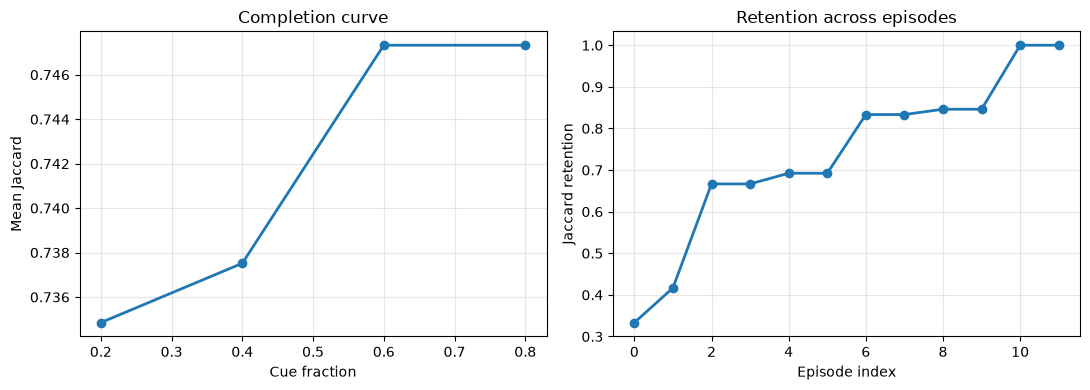


Modality dropout summary for mem2:
{'best_score': 0.735576923076923,
 'best_subset': 'sql+graph',
 'mean_score': 0.6912291412291411,
 'subset_scores': {'graph': 0.6126068376068377,
                   'sql': 0.725503663003663,
                   'sql+graph': 0.735576923076923},
 'worst_score': 0.6126068376068377,
 'worst_subset': 'graph'}

False retrieval summary for mem2:
{'false_retrieval_count': 12,
 'false_retrieval_rate': 1.0,
 'mean_best_impostor_overlap': 0.9743589743589745,
 'mean_margin': -0.23878205128205132,
 'mean_target_overlap': 0.735576923076923,
 'num_records': 12}

Exact lookup for the first stored episode:
{'age': 28, 'city': 'SF', 'dept': 'Core', 'role': 'Engineer', 'salary': 70000}

Provenance for the first stored episode:
{'ca3_assembly_size': 4,
 'dg_assembly_size': 24,
 'energy': 670000.0,
 'engram_id': 0,
 'episode_id': 0,
 'familiar': False,
 'graph_edge': (0, 'WORKS_AT', 1),
 'neuromodulator': 2.0,
 'predecessor_episode_id': None,
 'sql_row': {'age': 28,
     

In [3]:
sequence = [
    (
        {'age': 30, 'salary': 85000, 'city': 'NYC', 'role': 'Engineer', 'dept': 'Search'},
        (0, 'WORKS_AT', 1),
        'Alice joins Google',
    ),
    (
        {'age': 31, 'salary': 92000, 'city': 'NYC', 'role': 'Manager', 'dept': 'Search'},
        (0, 'MANAGES', 1),
        'Alice becomes manager',
    ),
    (
        {'age': 32, 'salary': 110000, 'city': 'Seattle', 'role': 'Engineer', 'dept': 'Cloud'},
        (0, 'WORKS_AT', 2),
        'Alice moves to Microsoft',
    ),
    (
        {'age': 34, 'salary': 180000, 'city': 'Seattle', 'role': 'CTO', 'dept': 'Cloud'},
        (0, 'MANAGES', 2),
        'Alice becomes CTO',
    ),
]

for episode_time, (sql_row, edge, text) in enumerate(sequence):
    mem.encode_episode(sql_row, edge, text=text, episode_time=float(episode_time))

for record in mem.episode_records[-4:]:
    print(
        f"episode {record.episode_id} | t={record.timestamp} | prev={record.predecessor_episode_id} | "
        f"next={record.successor_episode_id} | {record.text}"
    )


def previous_episode(memory, episode_id):
    record = memory.episode_records[episode_id]
    if record.predecessor_episode_id is None:
        return None
    return memory.episode_records[record.predecessor_episode_id]

current = mem.episode_records[-1]
prev = previous_episode(mem, current.episode_id)
print()
print('Current:', current.text)
print('Previous:', None if prev is None else prev.text)

mem2 = MultiModalMemory(use_text=False, seed=7)
continual_episodes = [
    ({'age': 28, 'salary': 70000, 'city': 'SF', 'role': 'Engineer', 'dept': 'Core'}, (0, 'WORKS_AT', 1), 'Episode A'),
    ({'age': 29, 'salary': 76000, 'city': 'SF', 'role': 'Engineer', 'dept': 'Core'}, (0, 'FRIENDS_WITH', 2), 'Episode B'),
    ({'age': 31, 'salary': 90000, 'city': 'Seattle', 'role': 'Manager', 'dept': 'Cloud'}, (2, 'MANAGES', 3), 'Episode C'),
    ({'age': 33, 'salary': 98000, 'city': 'Seattle', 'role': 'Manager', 'dept': 'Cloud'}, (3, 'REPORTS_TO', 0), 'Episode D'),
    ({'age': 35, 'salary': 120000, 'city': 'Austin', 'role': 'Architect', 'dept': 'Infra'}, (1, 'WORKS_AT', 2), 'Episode E'),
    ({'age': 37, 'salary': 145000, 'city': 'Austin', 'role': 'CTO', 'dept': 'Infra'}, (2, 'MANAGES', 0), 'Episode F'),
]

for sql_row, edge, text in continual_episodes:
    for _ in range(2):
        mem2.encode_episode(sql_row, edge, text=text, consolidate=True)

before = mem2.evaluate_interference()
completion_before = mem2.evaluate_completion_curve()
consolidation = mem2.consolidate(replay_passes=2)
after = mem2.evaluate_interference()
completion_after = mem2.evaluate_completion_curve()

print('Before consolidation:')
pprint(before)
print()
print('After consolidation:')
pprint(after)
print()
print('Consolidation run:')
pprint(consolidation)
print()
print('Completion curve after consolidation:')
pprint(completion_after)
print()
print('Separation metrics for mem2:')
pprint(mem2.evaluate_separation())
print()
print('Continuity metrics for mem2:')
pprint(mem2.evaluate_continuity())

fractions = np.array(sorted(completion_after['curve']))
values = np.array([completion_after['curve'][float(f)] for f in fractions])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fractions, values, marker='o', linewidth=2)
axes[0].set_title('Completion curve')
axes[0].set_xlabel('Cue fraction')
axes[0].set_ylabel('Mean Jaccard')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(len(after['retention'])), after['retention'], marker='o', linewidth=2)
axes[1].set_title('Retention across episodes')
axes[1].set_xlabel('Episode index')
axes[1].set_ylabel('Jaccard retention')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print()
print('Modality dropout summary for mem2:')
pprint(mem2.evaluate_modality_dropout())
print()
print('False retrieval summary for mem2:')
pprint(mem2.evaluate_false_retrieval_rate())
print()
print('Exact lookup for the first stored episode:')
pprint(mem2.exact_lookup(mem2.episode_records[0].episode_id))
print()
print('Provenance for the first stored episode:')
pprint(mem2.get_episode_provenance(mem2.episode_records[0].episode_id))


## v6

Small research harness that compares a few configurations and reports dropout, false retrieval, separation, continuity, and exactness metrics.


In [4]:
def micro_benchmark(use_text: bool, ca3_exc: int, consolidate: bool):
    model = MultiModalMemory(use_text=use_text, seed=11, ca3_exc=ca3_exc, text_use_pretrained=use_text)
    corpus = [
        ({'age': 30, 'salary': 85000, 'city': 'NYC', 'role': 'Engineer', 'dept': 'AI'}, (0, 'WORKS_AT', 1), 'Alice works at Google' if use_text else None),
        ({'age': 33, 'salary': 98000, 'city': 'Boston', 'role': 'Manager', 'dept': 'Research'}, (1, 'FRIENDS_WITH', 2), 'Bob collaborates with Carol' if use_text else None),
        ({'age': 36, 'salary': 126000, 'city': 'Seattle', 'role': 'Lead', 'dept': 'Cloud'}, (2, 'MANAGES', 3), 'Carol manages Dave' if use_text else None),
    ]

    def bridge_mean_weight(memory):
        weights = [syn.w for syn in memory.ca3.synapses if isinstance(syn.pre, str) and syn.pre.startswith('dg:')]
        return float(np.mean(weights)) if weights else 0.0

    def homeostatic_offset_mean(memory):
        offsets = [neuron.homeostatic_offset for neuron in memory.ca3.neurons[:memory.ca3.n_e]]
        return float(np.mean(offsets)) if offsets else 0.0

    bridge_before = bridge_mean_weight(model)
    homeostasis_before = homeostatic_offset_mean(model)

    for sql_row, edge, text in corpus:
        model.encode_episode(sql_row, edge, text=text, consolidate=consolidate)

    completion = model.evaluate_completion_curve()
    interference = model.evaluate_interference()
    separation = model.evaluate_separation()
    continuity = model.evaluate_continuity()
    dropout = model.evaluate_modality_dropout()
    false_retrieval = model.evaluate_false_retrieval_rate()
    bridge_after = bridge_mean_weight(model)
    homeostasis_after = homeostatic_offset_mean(model)

    return {
        'use_text': use_text,
        'ca3_exc': ca3_exc,
        'consolidate': consolidate,
        'mean_completion': completion['mean_completion'],
        'mean_retention': interference['mean_retention'],
        'separation_margin': separation['separation_margin_mean'],
        'separation_top1': separation['separation_top1_accuracy'],
        'false_retrieval_rate': false_retrieval['false_retrieval_rate'],
        'dropout_mean_score': dropout['mean_score'],
        'dropout_best_subset': dropout['best_subset'],
        'continuity_margin': continuity['continuity_margin_mean'],
        'continuity_links': continuity['link_consistency'],
        'bridge_weight_delta': bridge_after - bridge_before,
        'homeostatic_offset_mean': homeostasis_after,
        'final_assembly_size': len(model.episode_records[-1].ca3_assembly),
    }

benchmarks = [
    micro_benchmark(use_text=True, ca3_exc=240, consolidate=True),
    micro_benchmark(use_text=False, ca3_exc=240, consolidate=True),
    micro_benchmark(use_text=True, ca3_exc=480, consolidate=True),
    micro_benchmark(use_text=True, ca3_exc=240, consolidate=False),
]

for row in benchmarks:
    pprint(row)


{'bridge_weight_delta': 0.014135746470620214,
 'ca3_exc': 240,
 'consolidate': True,
 'continuity_links': 0.6666666666666666,
 'continuity_margin': 0.15000000000000013,
 'dropout_best_subset': 'sql+graph+text',
 'dropout_mean_score': 0.59359410430839,
 'false_retrieval_rate': 0.3333333333333333,
 'final_assembly_size': 6,
 'homeostatic_offset_mean': -0.3283333333333333,
 'mean_completion': 0.5217261904761904,
 'mean_retention': 0.9333333333333332,
 'separation_margin': 0.04444444444444443,
 'separation_top1': 0.6666666666666666,
 'use_text': True}
{'bridge_weight_delta': 0.021467983472738483,
 'ca3_exc': 240,
 'consolidate': True,
 'continuity_links': 0.6666666666666666,
 'continuity_margin': 0.09206349206349201,
 'dropout_best_subset': 'sql',
 'dropout_mean_score': 0.6205026455026456,
 'false_retrieval_rate': 0.6666666666666666,
 'final_assembly_size': 9,
 'homeostatic_offset_mean': -0.3233333333333333,
 'mean_completion': 0.5859006734006734,
 'mean_retention': 0.7464285714285714,
 's